<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_leader_follower_sync.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D11B_LEADER_FOLLOWER_SYNC — Directed Field Clock Synchronization

STATE: FOLLOWER_LOCKED
initial phase error: 2.706
final phase error: 0.7
final phase std: 0.0
initial frequency diff: 0.016969
final frequency diff: 0.0


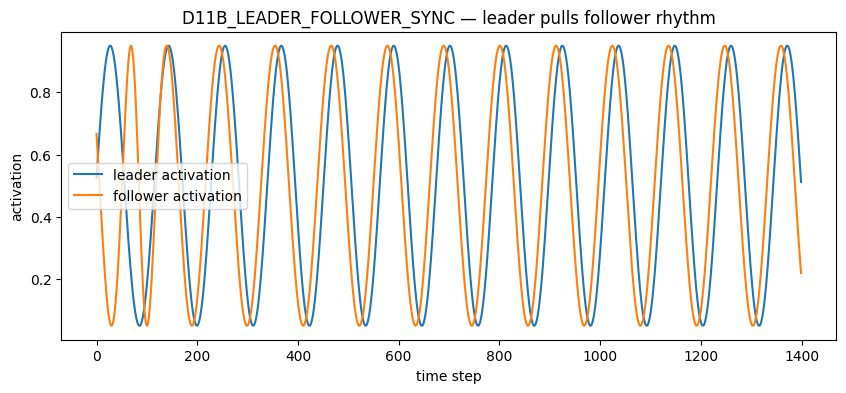

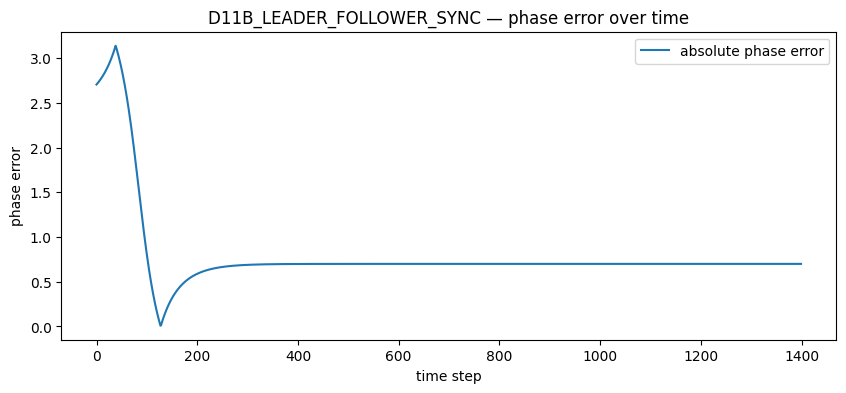

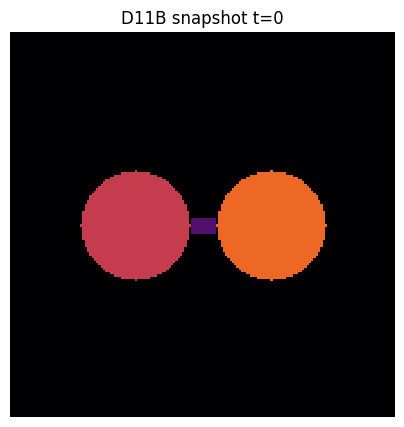

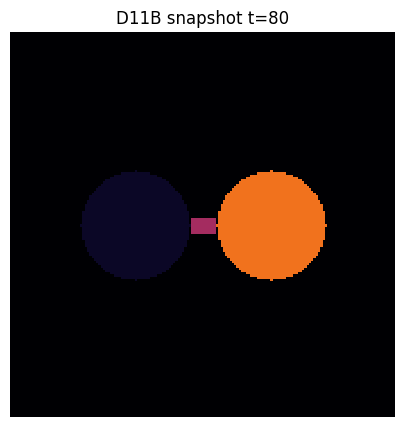

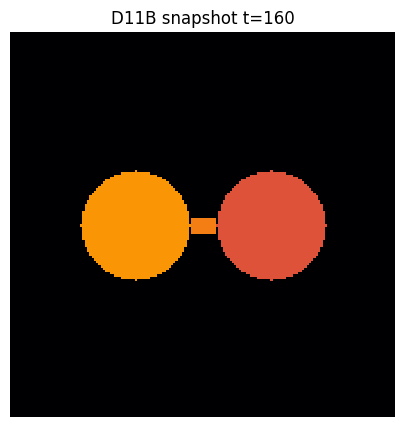

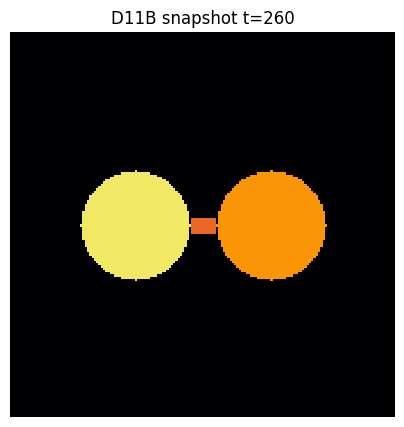

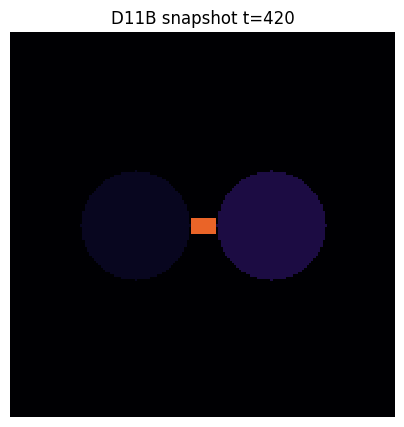

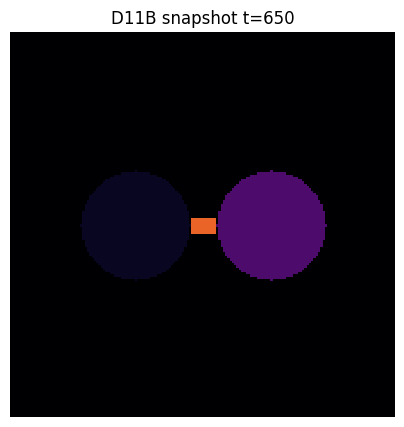

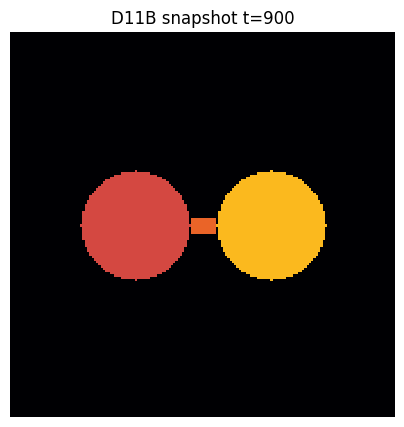

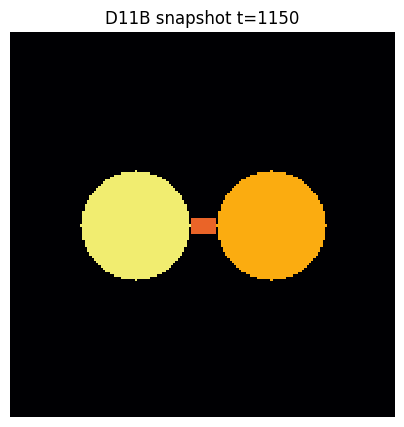

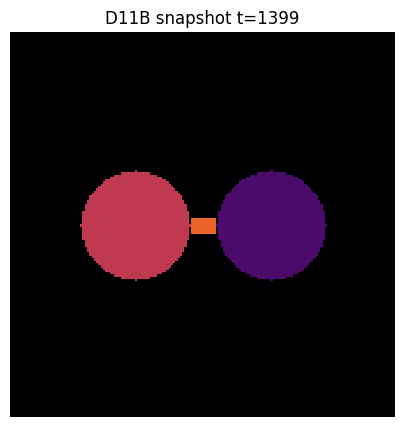

,STATE,RESULT,INITIAL_PHASE_ERROR,FINAL_PHASE_ERROR,FINAL_PHASE_STD,INITIAL_FREQ_DIFF,FINAL_FREQ_DIFF,LEADER_TO_FOLLOWER,FOLLOWER_TO_LEADER,LEADER_OMEGA,FOLLOWER_OMEGA
0,D11B_LEADER_FOLLOWER_SYNC,FOLLOWER_LOCKED,2.706,0.7,0.0,0.016969,0.0,0.55,0.04,1.1,1.48


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def wrap_angle(x):
    return np.angle(np.exp(1j * x))


def make_leader_follower_masks(size=170, radius=24):
    Y, X = np.ogrid[:size, :size]

    center_leader = (55, size // 2)
    center_follower = (115, size // 2)

    dist_leader = np.sqrt((X - center_leader[0]) ** 2 + (Y - center_leader[1]) ** 2)
    dist_follower = np.sqrt((X - center_follower[0]) ** 2 + (Y - center_follower[1]) ** 2)

    leader_cell = dist_leader <= radius
    follower_cell = dist_follower <= radius

    bridge = (
        (Y >= size // 2 - 3)
        & (Y <= size // 2 + 3)
        & (X > center_leader[0] + radius)
        & (X < center_follower[0] - radius)
    )

    return leader_cell, follower_cell, bridge, center_leader, center_follower


def render_leader_follower_field(
    size,
    leader_cell,
    follower_cell,
    bridge,
    leader_activation,
    follower_activation,
    phase_error,
):
    field = np.zeros((size, size), dtype=float)

    field[leader_cell] = leader_activation
    field[follower_cell] = follower_activation

    # Bridge becomes brighter as synchronization improves.
    bridge_strength = 0.15 + 0.65 * (1 - abs(phase_error) / np.pi)
    bridge_strength = float(np.clip(bridge_strength, 0, 1))

    field[bridge] = bridge_strength

    return field


def run_leader_follower_sync(
    size=170,
    steps=1400,
    dt=0.05,
    leader_omega=1.10,
    follower_omega=1.48,
    leader_to_follower=0.55,
    follower_to_leader=0.04,
    initial_leader_phase=0.0,
    initial_follower_phase=2.7,
):
    """
    D11B_LEADER_FOLLOWER_SYNC

    Directed synchronization model.

    Leader has stronger influence on follower.
    Follower has very weak influence on leader.

    This tests whether a weaker clock can align to a stronger master clock.
    """

    leader_cell, follower_cell, bridge, center_leader, center_follower = make_leader_follower_masks(size=size)

    theta_leader = initial_leader_phase
    theta_follower = initial_follower_phase

    history = []
    snapshots = {}

    for t in range(steps):
        phase_error = wrap_angle(theta_follower - theta_leader)

        # Leader is almost autonomous.
        dtheta_leader = leader_omega + follower_to_leader * np.sin(theta_follower - theta_leader)

        # Follower is strongly pulled by leader.
        dtheta_follower = follower_omega + leader_to_follower * np.sin(theta_leader - theta_follower)

        theta_leader += dt * dtheta_leader
        theta_follower += dt * dtheta_follower

        phase_error = wrap_angle(theta_follower - theta_leader)

        leader_activation = 0.5 + 0.45 * np.sin(theta_leader)
        follower_activation = 0.5 + 0.45 * np.sin(theta_follower)

        field = render_leader_follower_field(
            size=size,
            leader_cell=leader_cell,
            follower_cell=follower_cell,
            bridge=bridge,
            leader_activation=leader_activation,
            follower_activation=follower_activation,
            phase_error=phase_error,
        )

        history.append(
            {
                "t": t,
                "theta_leader": theta_leader,
                "theta_follower": theta_follower,
                "leader_activation": leader_activation,
                "follower_activation": follower_activation,
                "phase_error": phase_error,
                "abs_phase_error": abs(phase_error),
            }
        )

        if t in [0, 80, 160, 260, 420, 650, 900, 1150, steps - 1]:
            snapshots[t] = field.copy()

    history = pd.DataFrame(history)

    leader_unwrapped = np.unwrap(history["theta_leader"].values)
    follower_unwrapped = np.unwrap(history["theta_follower"].values)

    leader_freq = np.diff(leader_unwrapped)
    follower_freq = np.diff(follower_unwrapped)

    final_window = 250

    final_freq_diff = float(
        abs(leader_freq[-final_window:].mean() - follower_freq[-final_window:].mean())
    )

    final_phase_error = float(abs(history["phase_error"].iloc[-1]))
    final_phase_std = float(history["phase_error"].iloc[-final_window:].std())

    initial_phase_error = float(abs(history["phase_error"].iloc[0]))
    initial_freq_diff = float(abs(leader_freq[:final_window].mean() - follower_freq[:final_window].mean()))

    if final_freq_diff < 0.002 and final_phase_std < 0.035:
        result = "FOLLOWER_LOCKED"
    else:
        result = "NOT_LOCKED"

    summary = pd.DataFrame(
        [
            {
                "STATE": "D11B_LEADER_FOLLOWER_SYNC",
                "RESULT": result,
                "INITIAL_PHASE_ERROR": round(initial_phase_error, 3),
                "FINAL_PHASE_ERROR": round(final_phase_error, 3),
                "FINAL_PHASE_STD": round(final_phase_std, 3),
                "INITIAL_FREQ_DIFF": round(initial_freq_diff, 6),
                "FINAL_FREQ_DIFF": round(final_freq_diff, 6),
                "LEADER_TO_FOLLOWER": leader_to_follower,
                "FOLLOWER_TO_LEADER": follower_to_leader,
                "LEADER_OMEGA": leader_omega,
                "FOLLOWER_OMEGA": follower_omega,
            }
        ]
    )

    return history, snapshots, summary


history, snapshots, summary = run_leader_follower_sync()

print("STATE:", summary["RESULT"].iloc[0])
print("initial phase error:", summary["INITIAL_PHASE_ERROR"].iloc[0])
print("final phase error:", summary["FINAL_PHASE_ERROR"].iloc[0])
print("final phase std:", summary["FINAL_PHASE_STD"].iloc[0])
print("initial frequency diff:", summary["INITIAL_FREQ_DIFF"].iloc[0])
print("final frequency diff:", summary["FINAL_FREQ_DIFF"].iloc[0])

plt.figure(figsize=(10, 4))
plt.plot(history["t"], history["leader_activation"], label="leader activation")
plt.plot(history["t"], history["follower_activation"], label="follower activation")
plt.title("D11B_LEADER_FOLLOWER_SYNC — leader pulls follower rhythm")
plt.xlabel("time step")
plt.ylabel("activation")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["t"], history["abs_phase_error"], label="absolute phase error")
plt.title("D11B_LEADER_FOLLOWER_SYNC — phase error over time")
plt.xlabel("time step")
plt.ylabel("phase error")
plt.legend()
plt.show()

for t, snap in snapshots.items():
    plt.figure(figsize=(5, 5))
    plt.imshow(snap, cmap="inferno", vmin=0, vmax=1, interpolation="nearest")
    plt.title(f"D11B snapshot t={t}")
    plt.axis("off")
    plt.show()

summary